# Exploratory Data Analysis using Visualization Assignment

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset

df = pd.read_csv("/content/Titanic.csv")

In [3]:
# Display first 5 rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Check Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Interpretation

- Shows total rows and columns
- Displays data types
- Helps identify missing values

In [5]:
# Statistical Summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Interpretation

Provides statistical information like:

- Mean
- Median
- Minimum value
- Maximum value
- Standard deviation

In [6]:
# Check missing Values

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
# Fill Missing Values

# Fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
df.drop('Cabin', axis=1, inplace=True)

## Interpretation

- Median is used for Age because age contains numerical values and outliers.
- Mode is used for Embarked because it is a categorical column.
- Cabin is removed due to excessive missing values.

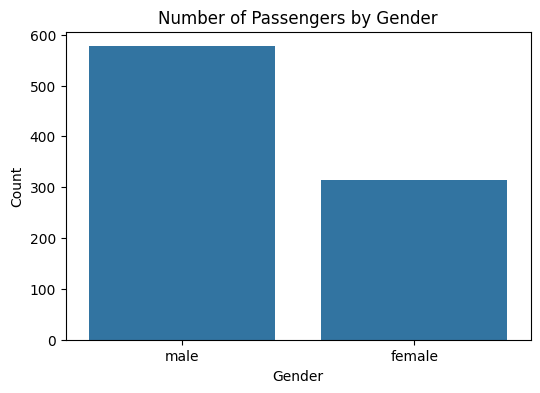

In [8]:
# Q1. Create a countplot to show the number of passengers by gender.

plt.figure(figsize=(6,4))

sns.countplot(x='Sex', data=df)

plt.title("Number of Passengers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

## Interpretation

- Male passengers are higher than female passengers.
- The Titanic dataset contains more men than women.

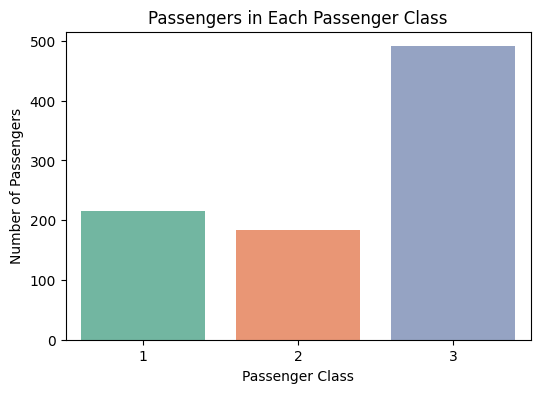

In [10]:
# Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.

plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', hue='Pclass', data=df, palette='Set2', legend=False)

plt.title("Passengers in Each Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

## Interpretation

- Most passengers belonged to 3rd class.
- 2nd class had the fewest passengers.

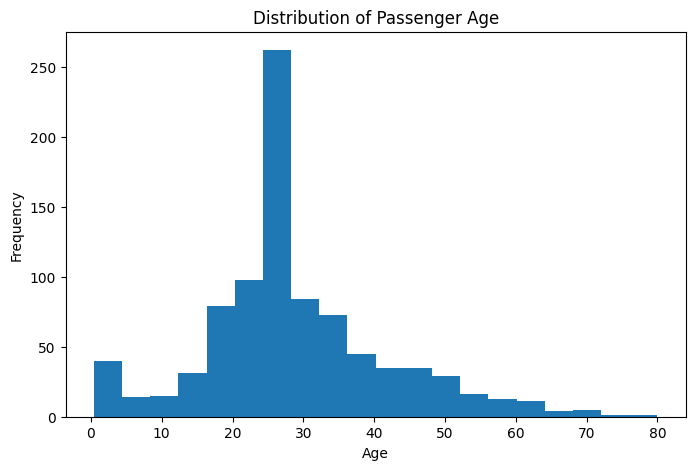

In [11]:
# Q3. Create a histogram to show the distribution of passenger age.

plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=20)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## Interpretation

- Most passengers were between 20-40 years old.
- Very few elderly passengers were present.

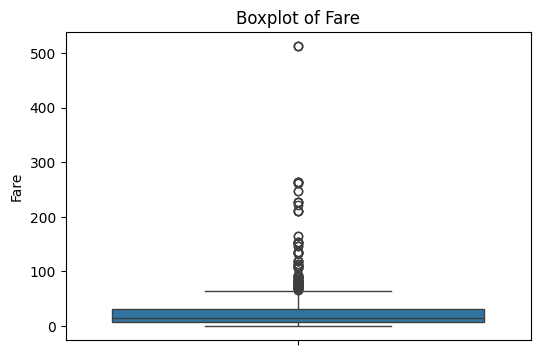

In [12]:
# Q4. Create a boxplot to detect outliers in the fare column.

plt.figure(figsize=(6,4))

sns.boxplot(y='Fare', data=df)

plt.title("Boxplot of Fare")

plt.show()

## Interpreatation

- Many outliers exist in the Fare column.
- Some passengers paid extremely high ticket prices.

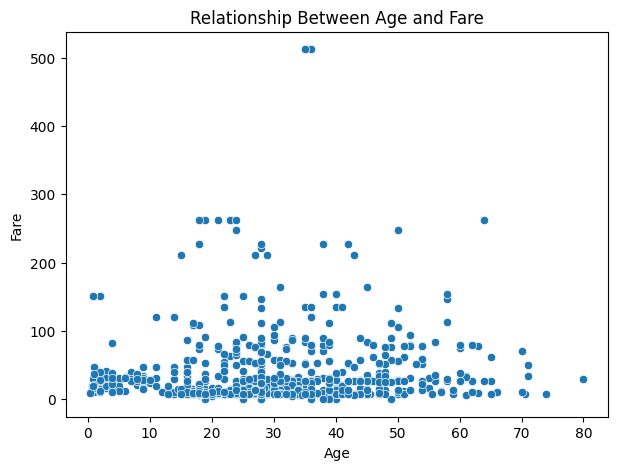

In [13]:
# Q5. Create a scatterplot to

# a. show the relationship between age and fare.
# b. analyze the relationship between family size (SibSp + Parch) and fare.

# (a) Scatterplot Between Age and Fare

plt.figure(figsize=(7,5))

sns.scatterplot(x='Age', y='Fare', data=df)

plt.title("Relationship Between Age and Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()



## Interpretation

- No strong relationship is visible between Age and Fare.
- Some paseengers paid high fares regardless of age.

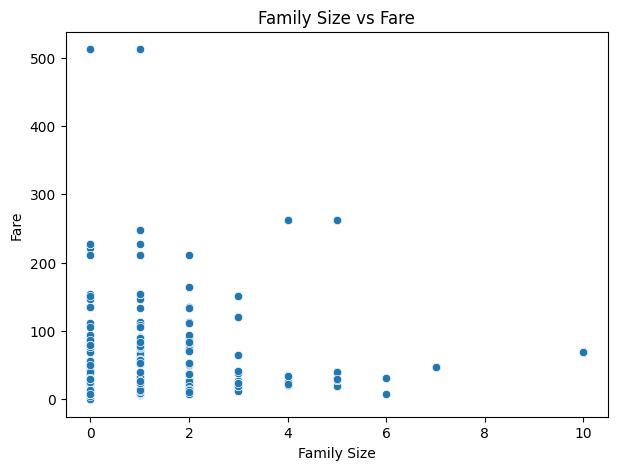

In [14]:
# (b) Scatterplot Between Family Size and Fare

# Create Family Size Column

df['Family_Size'] = df['SibSp'] + df['Parch']

# Scatterplot

plt.figure(figsize=(7,5))

sns.scatterplot(x='Family_Size', y='Fare', data=df)

plt.title("Family Size vs Fare")
plt.xlabel("Family Size")
plt.ylabel("Fare")

plt.show()

## Interpretation

- Passengers with larger families often paid high fares.
- Some small families also paid high fares because of class differences.

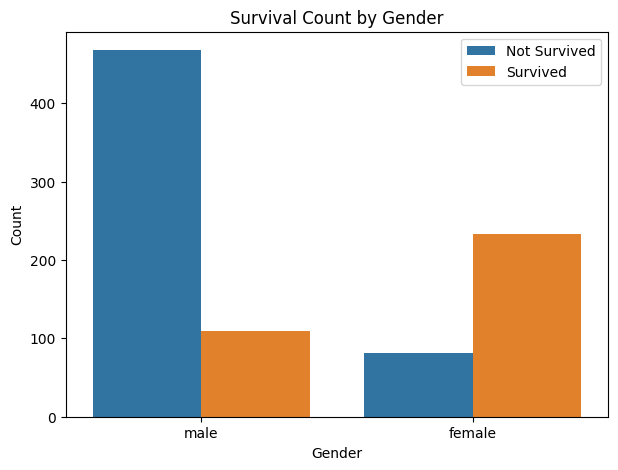

In [15]:
# Q6. Create a countplot to show survival count by gender.

plt.figure(figsize=(7,5))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(['Not Survived', 'Survived'])

plt.show()

## Interpretation

- Females had a higher survival rate.
- Many male passengers did not survive.

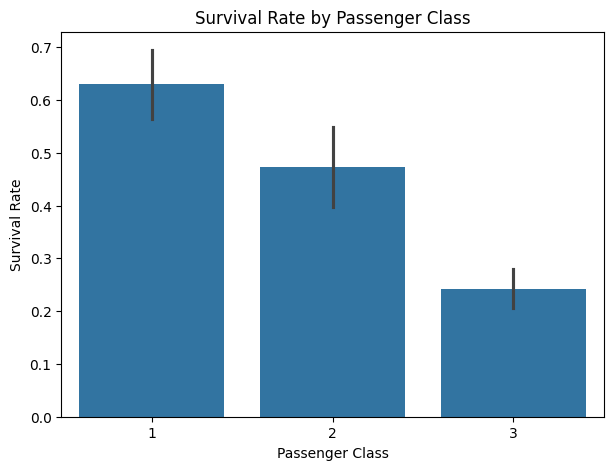

In [16]:
# Q7. Create a bar chart to show survival by passenger class.

plt.figure(figsize=(7,5))

sns.barplot(x='Pclass', y='Survived', data=df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

## Interpretation

- 1st class passengers had the highest survival rate.
- 3rd class passengers had the lowest survival rate.

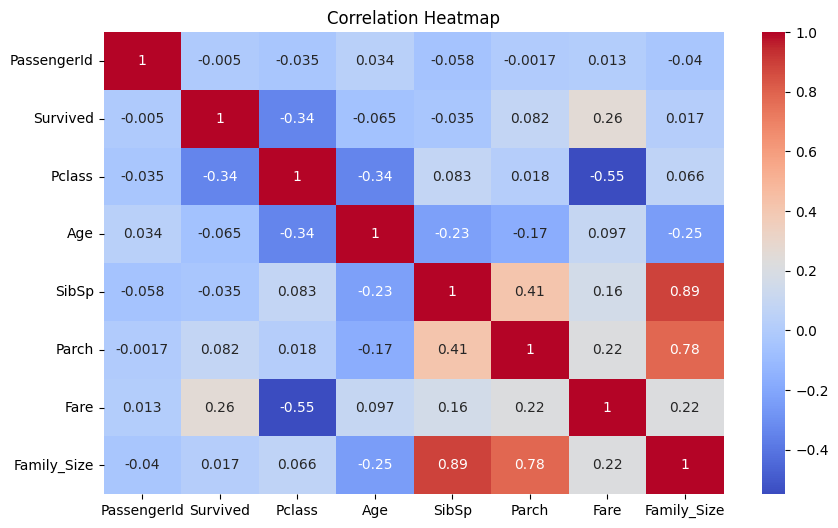

In [17]:
# Q8. Create a heatmap to show correlation between numerical variables.

plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

## Interpretation

- Fare and Pclass are negatively correlated.
- Survival has some positive relation with Fare.
- Family-related columns show moderate correlation.

In [18]:
# Q9. Identify which passenger class paid the highest fare on average.

avg_fare = df.groupby('Pclass')['Fare'].mean()

print(avg_fare)

# To find highest average fare

highest_class = avg_fare.idxmax()

print("Passenger class with highest average fare:", highest_class)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64
Passenger class with highest average fare: 1


## Interpretation

- 1st class passengers paid the highest average fare.
- Higher ticket prices indicate luxury travel.

## Q10. Write at least 5 insights from the dataset based on your visualizations.

### Five Important Insights

1. Most passengers on the Titanic belonged to 3rd class.

2. Female passengers had a much higher survival rate than male passengers.

3. 1st class passengers were more likely to survive.

4. The Fare column contains many outliers because some passengers paid very high ticket prices.

5. Most passengers were between the ages of 20 and 40 years.